In [4]:
#===========Mức 2: Dự đoán transaction amount================

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Đọc dữ liệu
file_path = '/content/Banking_Transactional_Dataset.xlsx'
df = pd.read_excel(file_path)

# 2. Feature Engineering (Khai phá đặc trưng thời gian)
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

# 3. Feature Selection (Loại bỏ các cột không có giá trị dự báo)
cols_to_drop = ['TransactionID', 'CustomerID', 'TransactionDate', 'BranchLat', 'BranchLong', 'Currency']
df_ml = df.drop(columns=cols_to_drop)

print("Kích thước dữ liệu sau khi loại bỏ cột thừa:", df_ml.shape)

Kích thước dữ liệu sau khi loại bỏ cột thừa: (20000, 16)


In [6]:
# 1. Tách biến mục tiêu (y) là số tiền giao dịch và các biến đầu vào (X)
X = df_ml.drop(columns=['Amount'])
y = df_ml['Amount']

# 2. Encoding Categorical Variables (Mã hóa One-Hot cho các cột chữ)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Train/Test Split (Chia tập dữ liệu 80% Train - 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Data Scaling (Chuẩn hóa thang đo dữ liệu)
scaler = StandardScaler()
# Lưu ý: Chỉ fit trên tập Train để tránh rò rỉ dữ liệu (Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Kích thước tập Train:", X_train_scaled.shape)
print("Kích thước tập Test:", X_test_scaled.shape)

Kích thước tập Train: (16000, 39)
Kích thước tập Test: (4000, 39)


In [7]:
# Khởi tạo 3 mô hình cơ bản
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

results = []
print("Đang huấn luyện và đánh giá các mô hình cơ bản...\n")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Mô hình": name,
        "MAE": round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "R² Score": round(r2_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

Đang huấn luyện và đánh giá các mô hình cơ bản...



,Mô hình,MAE,RMSE,R² Score
0,Linear Regression,2535.24,3075.49,0.2472
1,Random Forest,2592.28,3177.67,0.1964
2,XGBoost,2629.17,3253.64,0.1575


In [8]:
#========Mức 3: Forecasting&PrescriptiveAnalytics==========

   ATM  Mobile  Online   Fee  TotalVolume  TotalRevenue  TotalFeeRevenue  BranchScore
0  0.0     0.0     0.0 -0.05      19595.0  9.899119e+07     1.880833e+06     0.536839
1  0.0     0.0     0.0  0.00      19595.0  9.899119e+07     1.979824e+06     0.536839
2  0.0     0.0     0.0  0.10      19595.0  9.899119e+07     2.177806e+06     0.536839
3  0.0     0.0     0.1 -0.05      20071.4  1.013903e+08     1.880833e+06     0.533195
4  0.0     0.0     0.1  0.00      20071.4  1.013903e+08     1.979824e+06     0.533195


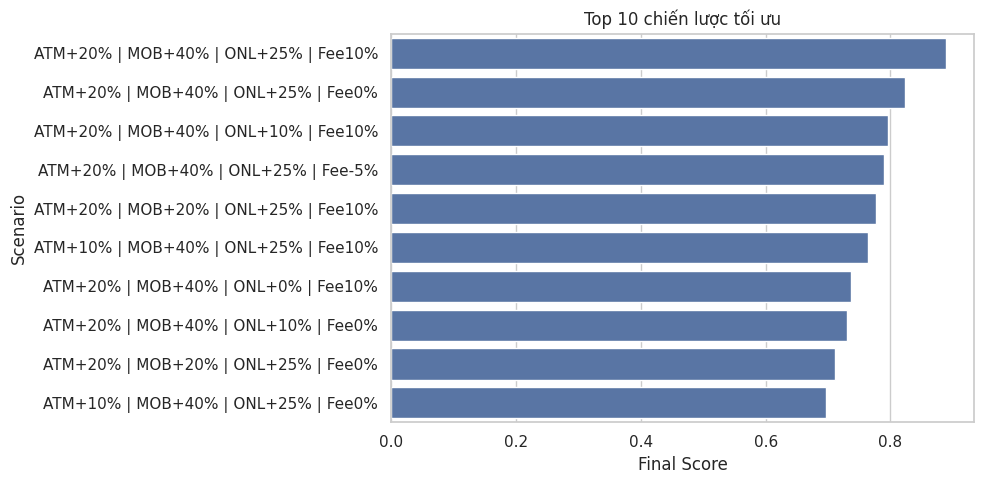


RECOMMENDATION

========== PRESCRIPTIVE ANALYTICS ==========
Chiến lược kinh doanh tối ưu:

1. ATM
   → Mở rộng quy mô giao dịch ATM:+20%


2. Mobile Banking
   → Đầu tư phát triển Mobile Banking:+40%


3. Online Banking
   → Khuyến khích giao dịch Online:+25%


4. Chính sách phí
   → Điều chỉnh Fee:+10%


Đánh giá tác động:

Final Score:
0.889

Mục tiêu tối ưu:
✓ Transaction Volume
✓ Channel Revenue
✓ Branch Performance

=> Khuyến nghị ngân hàng ưu tiên chiến lược
phát triển kênh số kết hợp mở rộng ATM.



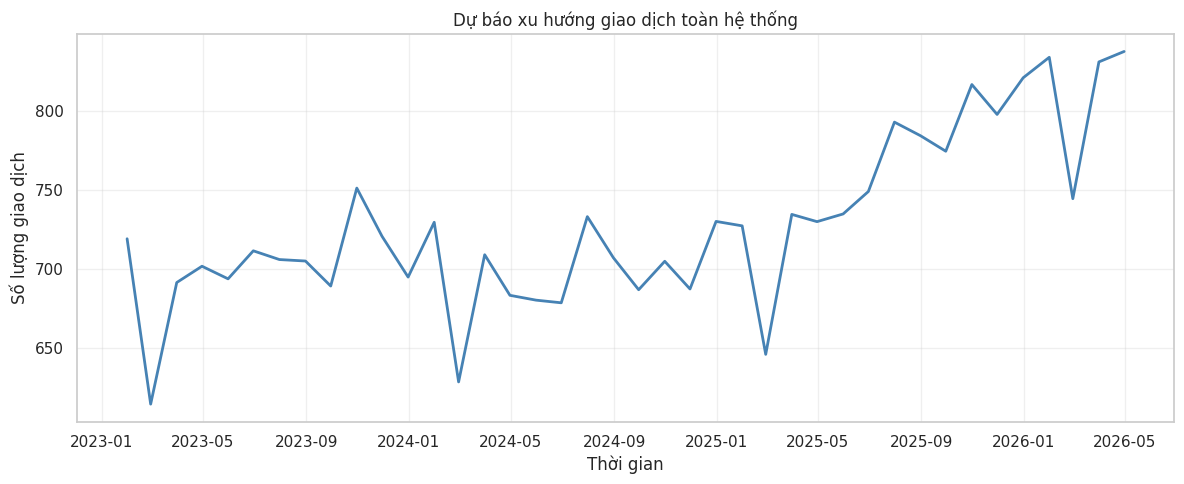

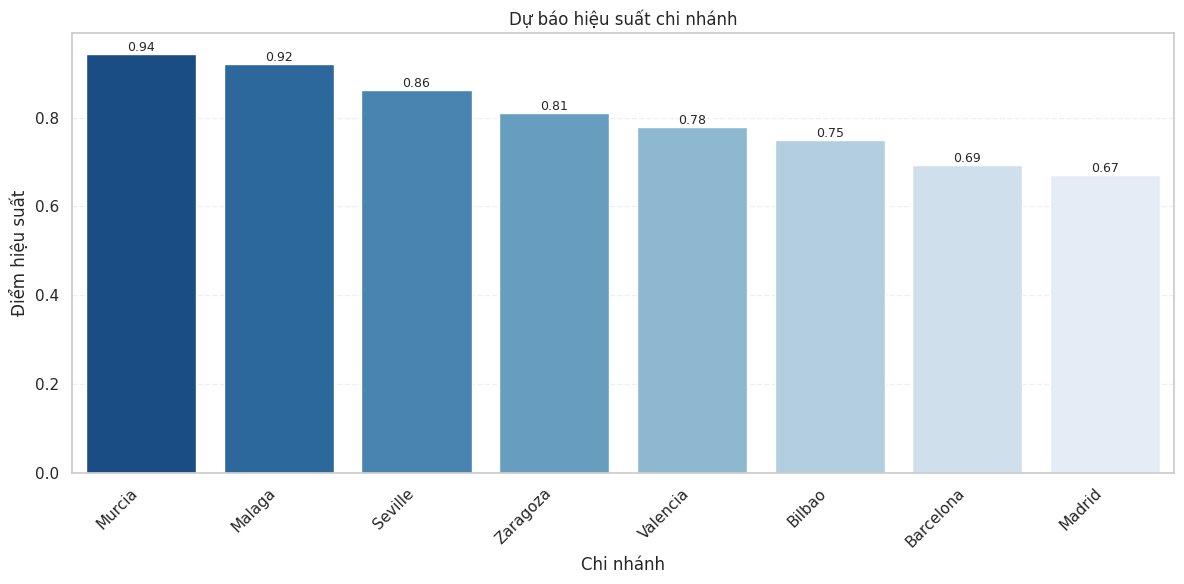

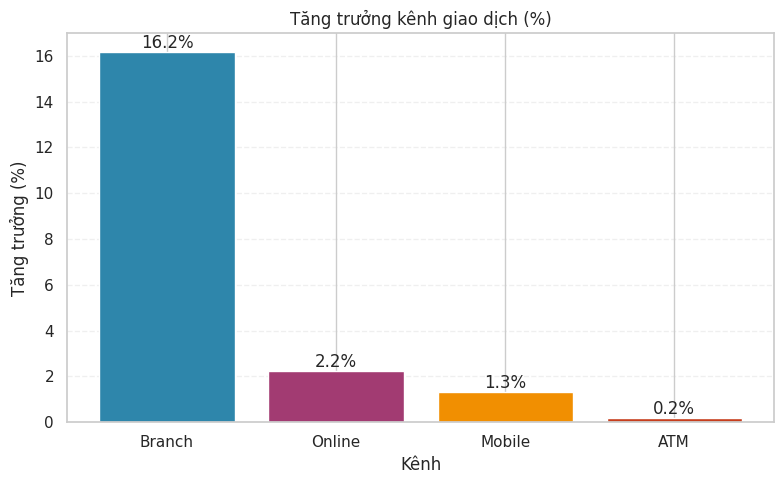


TOP 10 STRATEGIES


,ATM,Mobile,Online,Fee,VolumeNorm,RevenueNorm,BranchNorm,FeeRevenueNorm,FinalScore
80,0.2,0.4,0.25,0.10,1.000,1.000,0.447,1.000,0.889
79,0.2,0.4,0.25,0.00,1.000,1.000,0.447,0.333,0.823
77,0.2,0.4,0.10,0.10,0.830,0.830,0.578,1.000,0.797
78,0.2,0.4,0.25,-0.05,1.000,1.000,0.447,0.000,0.789
71,0.2,0.2,0.25,0.10,0.756,0.757,0.740,1.000,0.777
53,0.1,0.4,0.25,0.10,0.886,0.884,0.221,1.000,0.764
74,0.2,0.4,0.00,0.10,0.716,0.717,0.677,1.000,0.737
76,0.2,0.4,0.10,0.00,0.830,0.830,0.578,0.333,0.730
70,0.2,0.2,0.25,0.00,0.756,0.757,0.740,0.333,0.711
52,0.1,0.4,0.25,0.00,0.886,0.884,0.221,0.333,0.697


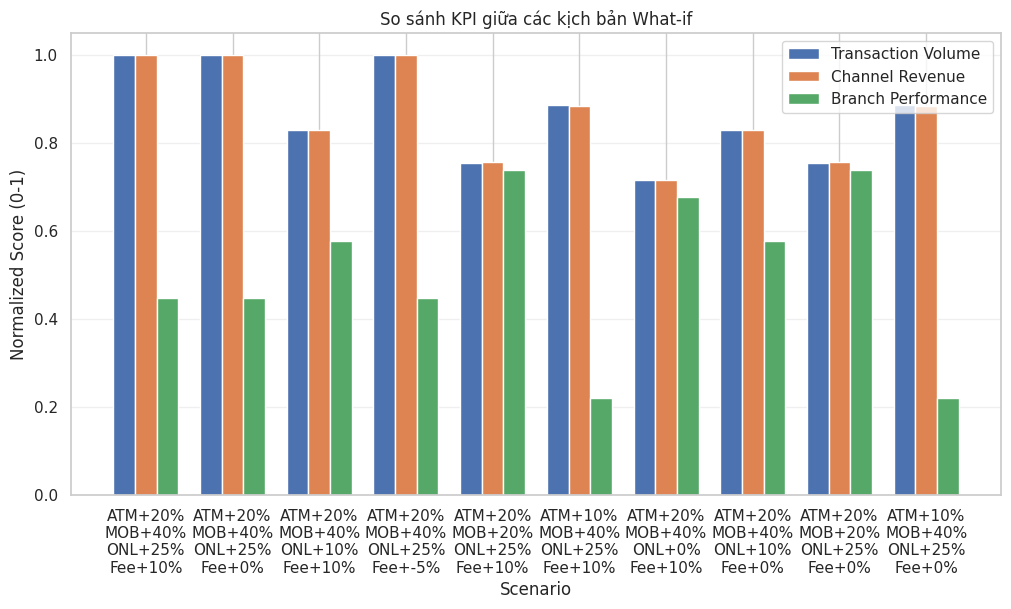

In [9]:
from prophet import Prophet
import logging

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').disabled = True

sns.set(style="whitegrid")

# =========================
# 1. LOAD DATA
# =========================
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# =========================
# 2. REMOVE INCOMPLETE MONTH (05/2025)
# =========================
df = df[~(
    (df['TransactionDate'].dt.year == 2025) &
    (df['TransactionDate'].dt.month == 5)
)]

# =========================
# 3. FEATURE ENGINEERING
# =========================
df['FeeRevenue'] = df['Amount'] * 0.02
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

# =========================
# 4. GLOBAL FORECAST
# =========================
monthly_volume = df.groupby(
    pd.Grouper(key='TransactionDate', freq='ME')
).size().reset_index(name='Volume')

forecast_data = monthly_volume.rename(columns={'TransactionDate': 'ds', 'Volume': 'y'})

model_global = Prophet()
model_global.fit(forecast_data)

future_global = model_global.make_future_dataframe(periods=12, freq='ME')
forecast_global = model_global.predict(future_global)

# =========================
# 5. BRANCH PERFORMANCE SCORE (WITH FEE REVENUE)
# =========================
branch_monthly = df.groupby(
    ['BranchCity', pd.Grouper(key='TransactionDate', freq='ME')]
).agg({
    'TransactionID': 'count',
    'Amount': 'sum',
    'FeeRevenue': 'sum'
}).reset_index()

branch_monthly.columns = ['BranchCity', 'Date', 'Volume', 'Amount', 'FeeRevenue']

# Normalize
branch_monthly['VolumeNorm'] = branch_monthly['Volume'] / branch_monthly['Volume'].max()
branch_monthly['RevenueNorm'] = branch_monthly['Amount'] / branch_monthly['Amount'].max()
branch_monthly['FeeNorm'] = branch_monthly['FeeRevenue'] / branch_monthly['FeeRevenue'].max()

branch_monthly['BranchPerformance'] = (
    0.4 * branch_monthly['VolumeNorm'] +
    0.4 * branch_monthly['RevenueNorm'] +
    0.2 * branch_monthly['FeeNorm']
)

# =========================
# 6. BRANCH FORECAST
# =========================
cities = branch_monthly['BranchCity'].unique()

branch_result = []

for city in cities:

    data = branch_monthly[branch_monthly['BranchCity'] == city][['Date', 'BranchPerformance']]
    data = data.rename(columns={'Date': 'ds', 'BranchPerformance': 'y'}).dropna()

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=12, freq='ME')
    forecast = model.predict(future)

    branch_result.append({
        'BranchCity': city,
        'ForecastPerformance': forecast['yhat'].iloc[-1]
    })

branch_result = pd.DataFrame(branch_result).sort_values('ForecastPerformance', ascending=False)

# =========================
# 7. CHANNEL FORECAST
# =========================
channel_monthly = df.groupby(
    ['Channel', pd.Grouper(key='TransactionDate', freq='ME')]
).size().reset_index(name='Volume')

channels = channel_monthly['Channel'].unique()

channel_result = []

for ch in channels:

    data = channel_monthly[channel_monthly['Channel'] == ch][['TransactionDate', 'Volume']]
    data = data.rename(columns={'TransactionDate': 'ds', 'Volume': 'y'})

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=12, freq='ME')
    forecast = model.predict(future)

    current = data['y'].tail(12).mean()
    future_avg = forecast['yhat'].tail(12).mean()

    growth = 0 if current == 0 else (future_avg - current) / current * 100

    channel_result.append({
        'Channel': ch,
        'GrowthRate': growth,
        'ForecastVolume': future_avg
    })

channel_result = pd.DataFrame(channel_result).sort_values('GrowthRate', ascending=False)

# =====================================================
# 8. WHAT-IF ANALYSIS + SIMULATION ANALYTICS
# =====================================================

scenarios = []

atm_growth = [0, 0.1, 0.2]
mobile_growth = [0, 0.2, 0.4]
online_growth = [0, 0.1, 0.25]
fee_change = [-0.05, 0, 0.1]

for atm in atm_growth:
    for mobile in mobile_growth:
        for online in online_growth:
            for fee in fee_change:

                temp = df.copy()

                # =========================
                # Transaction Volume
                # =========================

                temp['VolumeFactor'] = temp['Channel'].map({
                    'ATM': 1 + atm,
                    'Mobile': 1 + mobile,
                    'Online': 1 + online
                }).fillna(1)

                # số lượng giao dịch mô phỏng
                temp['SimVolume'] = temp['VolumeFactor']

                total_volume = temp['SimVolume'].sum()

                # =========================
                # Revenue
                # =========================

                temp['SimRevenue'] = (
                    temp['Amount']
                    * temp['VolumeFactor']
                )
                temp['SimFee'] = (
                    temp['FeeRevenue']
                    * (1 + fee)
                )

                total_revenue = temp['SimRevenue'].sum()
                total_fee_revenue = temp['SimFee'].sum()

                # =========================
                # =========================
                # Branch Performance
                # =========================

                branch_perf = temp.groupby('BranchCity').agg({
                    'SimVolume': 'sum',
                    'SimRevenue': 'sum',
                    'SimFee': 'sum'
                }).reset_index()

                branch_perf['VolumeNorm'] = (
                    branch_perf['SimVolume']
                    - branch_perf['SimVolume'].min()
                ) / (
                    branch_perf['SimVolume'].max()
                    - branch_perf['SimVolume'].min()
                )

                branch_perf['RevenueNorm'] = (
                    branch_perf['SimRevenue']
                    - branch_perf['SimRevenue'].min()
                ) / (
                    branch_perf['SimRevenue'].max()
                    - branch_perf['SimRevenue'].min()
                )

                branch_perf['FeeNorm'] = (
                    branch_perf['SimFee']
                    - branch_perf['SimFee'].min()
                ) / (
                    branch_perf['SimFee'].max()
                    - branch_perf['SimFee'].min()
                )

                branch_perf['Score'] = (
                    0.4 * branch_perf['VolumeNorm']
                    + 0.4 * branch_perf['RevenueNorm']
                    + 0.2 * branch_perf['FeeNorm']
                )

                avg_branch_score = branch_perf['Score'].mean()

                scenarios.append({
                  'ATM': atm,
                  'Mobile': mobile,
                  'Online': online,
                  'Fee': fee,
                  'TotalVolume': total_volume,
                  'TotalRevenue': total_revenue,
                  'TotalFeeRevenue': total_fee_revenue,
                  'BranchScore': avg_branch_score
              })

simulation_df = pd.DataFrame(scenarios)
print(simulation_df.head())

# =====================================================
# KPI NORMALIZATION
# =====================================================

simulation_df['VolumeNorm'] = (
    simulation_df['TotalVolume']
    - simulation_df['TotalVolume'].min()
) / (
    simulation_df['TotalVolume'].max()
    - simulation_df['TotalVolume'].min()
)

simulation_df['RevenueNorm'] = (
    simulation_df['TotalRevenue']
    - simulation_df['TotalRevenue'].min()
) / (
    simulation_df['TotalRevenue'].max()
    - simulation_df['TotalRevenue'].min()
)

simulation_df['BranchNorm'] = (
    simulation_df['BranchScore']
    - simulation_df['BranchScore'].min()
) / (
    simulation_df['BranchScore'].max()
    - simulation_df['BranchScore'].min()
)
simulation_df['FeeRevenueNorm'] = (
    simulation_df['TotalFeeRevenue']
    - simulation_df['TotalFeeRevenue'].min()
) / (
    simulation_df['TotalFeeRevenue'].max()
    - simulation_df['TotalFeeRevenue'].min()
)
# =====================================================
# FINAL SCORE
# =====================================================

simulation_df['FinalScore'] = (
    0.35 * simulation_df['VolumeNorm']
    + 0.35 * simulation_df['RevenueNorm']
    + 0.20 * simulation_df['BranchNorm']
    + 0.10 * simulation_df['FeeRevenueNorm']
)

simulation_df = simulation_df.sort_values(
    'FinalScore',
    ascending=False
)

plt.figure(figsize=(10,5))

top10 = simulation_df.head(10).copy()

top10['Scenario'] = top10.apply(
    lambda x:
    f"ATM+{int(x['ATM']*100)}% | "
    f"MOB+{int(x['Mobile']*100)}% | "
    f"ONL+{int(x['Online']*100)}% | "
    f"Fee{int(x['Fee']*100)}%",
    axis=1
)

sns.barplot(
    data=top10,
    x='FinalScore',
    y='Scenario'
)
plt.title("Top 10 chiến lược tối ưu")
plt.xlabel("Final Score")
plt.ylabel("Scenario")
plt.tight_layout()
plt.show()
# =========================
# 10. PRESCRIPTIVE ANALYTICS
# =========================
best_strategy = simulation_df.iloc[0]

print("\nRECOMMENDATION")

print(
f"""
========== PRESCRIPTIVE ANALYTICS ==========
Chiến lược kinh doanh tối ưu:

1. ATM
   → Mở rộng quy mô giao dịch ATM:+{best_strategy['ATM']*100:.0f}%


2. Mobile Banking
   → Đầu tư phát triển Mobile Banking:+{best_strategy['Mobile']*100:.0f}%


3. Online Banking
   → Khuyến khích giao dịch Online:+{best_strategy['Online']*100:.0f}%


4. Chính sách phí
   → Điều chỉnh Fee:+{best_strategy['Fee']*100:.0f}%


Đánh giá tác động:

Final Score:
{best_strategy['FinalScore']:.3f}

Mục tiêu tối ưu:
✓ Transaction Volume
✓ Channel Revenue
✓ Branch Performance

=> Khuyến nghị ngân hàng ưu tiên chiến lược
phát triển kênh số kết hợp mở rộng ATM.
"""
)
# =========================
# 11. VISUALIZATION (CLEAR + BUSINESS STYLE)
# =========================

# Global forecast
plt.figure(figsize=(12,5))

plt.plot(
    forecast_global['ds'],
    forecast_global['yhat'],
    linewidth=2,
    color='steelblue'
)

plt.title("Dự báo xu hướng giao dịch toàn hệ thống")
plt.xlabel("Thời gian")
plt.ylabel("Số lượng giao dịch")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Branch performance
plt.figure(figsize=(12,6))

branch_sorted = branch_result.sort_values('ForecastPerformance', ascending=False)

ax = sns.barplot(
    data=branch_sorted,
    x='BranchCity',
    y='ForecastPerformance',
    hue='BranchCity',
    palette='Blues_r',
    legend=False
)

plt.title("Dự báo hiệu suất chi nhánh")
plt.xlabel("Chi nhánh")
plt.ylabel("Điểm hiệu suất")

plt.xticks(rotation=45, ha='right')

# label rõ hơn
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Channel growth
plt.figure(figsize=(8,5))

channel_sorted = channel_result.sort_values('GrowthRate', ascending=False)

bars = plt.bar(
    channel_sorted['Channel'],
    channel_sorted['GrowthRate'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
)

plt.title("Tăng trưởng kênh giao dịch (%)")
plt.xlabel("Kênh")
plt.ylabel("Tăng trưởng (%)")

plt.xticks(rotation=0)

for b in bars:
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.1f}%",
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
# Simulation
# ====================================
# TOP 10 SCENARIOS
# ====================================
print("\nTOP 10 STRATEGIES")

top = simulation_df.head(10).copy()

top_display = top[
    [
        'ATM',
        'Mobile',
        'Online',
        'Fee',
        'VolumeNorm',
        'RevenueNorm',
        'BranchNorm',
        'FeeRevenueNorm',
        'FinalScore'
    ]
].round(3)

display(top_display)
top['Scenario'] = top.apply(
    lambda x:
    f"ATM+{int(x['ATM']*100)}%\n"
    f"MOB+{int(x['Mobile']*100)}%\n"
    f"ONL+{int(x['Online']*100)}%\n"
    f"Fee+{int(x['Fee']*100)}%",
    axis=1
)

plt.figure(figsize=(12,6))

x = np.arange(len(top))
w = 0.25

plt.bar(
    x-w,
    top['VolumeNorm'],
    width=w,
    label='Transaction Volume'
)

plt.bar(
    x,
    top['RevenueNorm'],
    width=w,
    label='Channel Revenue'
)

plt.bar(
    x+w,
    top['BranchNorm'],
    width=w,
    label='Branch Performance'
)

plt.xticks(x, top['Scenario'])

plt.ylabel('Normalized Score (0-1)')
plt.xlabel('Scenario')
plt.title('So sánh KPI giữa các kịch bản What-if')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [10]:
# 1. Tính toán Revenue Forecast (Doanh thu dự báo)
# Giả định doanh thu mỗi giao dịch là trung bình cộng của dữ liệu gốc
avg_revenue_per_tx = df['FeeRevenue'].sum() / df['TransactionID'].count()

# Tạo dataframe doanh thu dự báo từ kết quả dự báo toàn hệ thống (forecast_global)
revenue_forecast = forecast_global[['ds', 'yhat']].copy()
revenue_forecast['ForecastRevenue'] = revenue_forecast['yhat'] * avg_revenue_per_tx
revenue_forecast.columns = ['Date', 'ForecastVolume', 'ForecastRevenue']

# 2. Lưu tất cả vào file Excel
with pd.ExcelWriter("Banking_Analytics_Result.xlsx") as writer:
    # Kết quả mô phỏng What-If
    simulation_df.to_excel(writer, sheet_name="WhatIf", index=False)

    # Kết quả dự báo chi nhánh
    branch_result.to_excel(writer, sheet_name="BranchForecast", index=False)

    # Kết quả dự báo kênh
    channel_result.to_excel(writer, sheet_name="ChannelForecast", index=False)

    # Kết quả doanh thu dự báo
    revenue_forecast.to_excel(writer, sheet_name="RevenueForecast", index=False)

print("Đã xuất file thành công: Banking_Analytics_Result.xlsx")

Đã xuất file thành công: Banking_Analytics_Result.xlsx
